In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.preprocessing import (OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score, roc_auc_score, precision_score, recall_score
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

In [86]:
df = pd.read_csv('heart.csv')

In [87]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [88]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [89]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f'{col}: {df[col].unique()}')
    else:
        print(f'{col}: {df[col].describe()}')

Age: count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64
Sex: ['M' 'F']
ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
RestingBP: count    918.000000
mean     132.396514
std       18.514154
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64
Cholesterol: count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64
FastingBS: count    918.000000
mean       0.233115
std        0.423046
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: FastingBS, dtype: float64
RestingECG: ['Normal' 'ST' 'LVH']
MaxHR: count    918.000000
mean     136.809368
std       25.460334
min       60.000000
25%      120.000000


In [90]:
print(df.dtypes)

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


([<matplotlib.axis.XTick at 0x1b0fd43e440>,
 [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

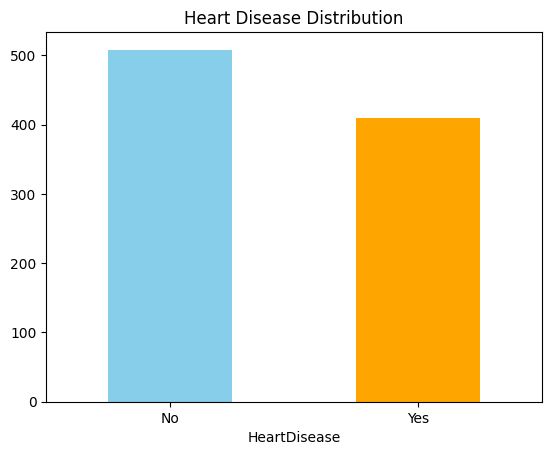

In [91]:
df['HeartDisease'].value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Heart Disease Distribution")
plt.xticks(rotation=0, ticks=[0,1], labels=['No', 'Yes'])

In [92]:
df['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [93]:
df['RestingECG'].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [94]:
df['ST_Slope'].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

In [95]:
df['Sex'] = df['Sex'].apply(lambda x: 1 if x == 'M' else 0)
df['ExerciseAngina'] = df['ExerciseAngina'].apply(lambda x: 1 if x == 'Y' else 0)


In [96]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,TA,110,264,0,Normal,132,0,1.2,Flat,1
914,68,1,ASY,144,193,1,Normal,141,0,3.4,Flat,1
915,57,1,ASY,130,131,0,Normal,115,1,1.2,Flat,1
916,57,0,ATA,130,236,0,LVH,174,0,0.0,Flat,1


In [97]:
df[(df['Age']<35) & (df['HeartDisease']==1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
56,31,1,ASY,120,270,0,Normal,153,1,1.5,Flat,1
76,32,1,ASY,118,529,0,Normal,130,0,0.0,Flat,1
115,33,0,ASY,100,246,0,Normal,150,1,1.0,Flat,1
119,34,1,TA,140,156,0,Normal,180,0,0.0,Flat,1
294,32,1,TA,95,0,1,Normal,127,0,0.7,Up,1
313,34,1,ASY,115,0,1,Normal,154,0,0.2,Up,1


In [98]:
cols_to_encode = ['ChestPainType', 'RestingECG', 'ST_Slope']

In [99]:
df_corr = df.copy()
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df_corr[cols_to_encode])
cols = encoder.get_feature_names_out()
encoded_df = pd.DataFrame(encoded_data, columns=cols)
df_corr = pd.concat([df_corr.drop(cols_to_encode, axis=1), encoded_df], axis=1)
df_corr

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,0,160,180,0,156,0,1.0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,1,130,283,0,98,0,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48,0,138,214,0,108,1,1.5,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54,1,150,195,0,122,0,0.0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,132,0,1.2,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
914,68,1,144,193,1,141,0,3.4,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
915,57,1,130,131,0,115,1,1.2,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
916,57,0,130,236,0,174,0,0.0,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [100]:
df_corr.corr()['HeartDisease'].abs().sort_values(ascending=False)

HeartDisease         1.000000
ST_Slope_Up          0.622164
ST_Slope_Flat        0.554134
ChestPainType_ASY    0.516716
ExerciseAngina       0.494282
Oldpeak              0.403951
ChestPainType_ATA    0.401924
MaxHR                0.400421
Sex                  0.305445
Age                  0.282039
FastingBS            0.267291
Cholesterol          0.232741
ChestPainType_NAP    0.212964
ST_Slope_Down        0.122527
RestingBP            0.107589
RestingECG_ST        0.102527
RestingECG_Normal    0.091580
ChestPainType_TA     0.054790
RestingECG_LVH       0.010670
Name: HeartDisease, dtype: float64

In [101]:
correlations = df_corr.corr()['HeartDisease'].abs()
sorted_correlations = correlations.sort_values()
num_of_cols_to_drop = int(0.3*len(df.columns))
cols_to_drop = sorted_correlations.iloc[:num_of_cols_to_drop].index
df_dropped = df_corr.drop(cols_to_drop, axis=1)

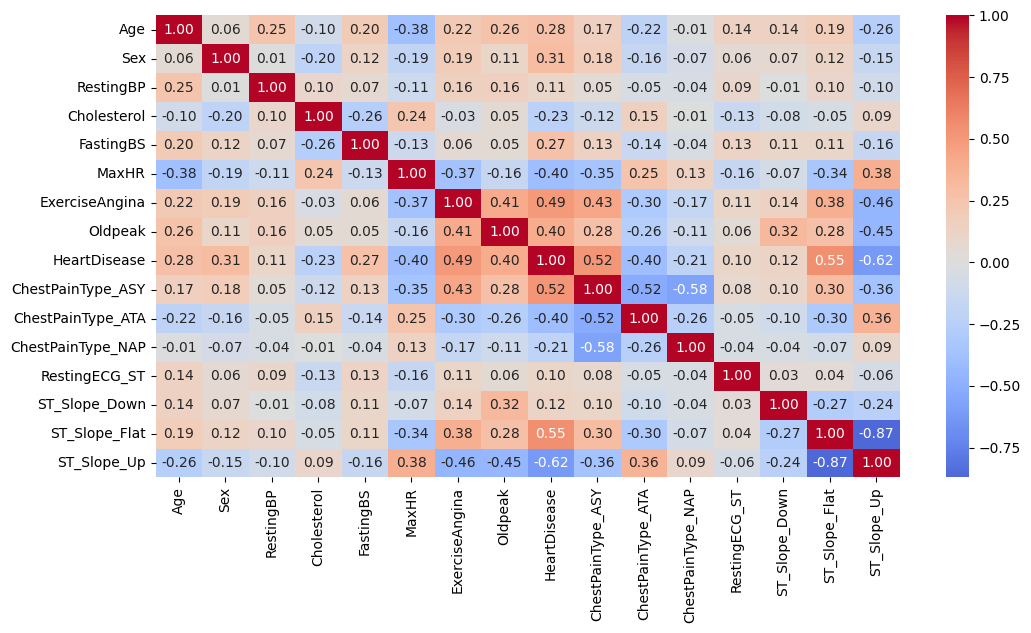

In [102]:
plt.figure(figsize=(12,6))
sns.heatmap(df_dropped.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

In [103]:
df.describe()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,132.396514,198.799564,0.233115,136.809368,0.404139,0.887364,0.553377
std,9.432617,0.407701,18.514154,109.384145,0.423046,25.460334,0.490992,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000
25%,47.000000,1.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,130.000000,223.000000,0.000000,138.000000,0.000000,0.600000,1.000000
75%,60.000000,1.000000,140.000000,267.000000,0.000000,156.000000,1.000000,1.500000,1.000000
max,77.000000,1.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,1.000000


In [ ]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

## RandomForestClassifier

- `NB` It's wrong due to data leakage


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50,70,100],
    'criterion':['gini', 'entropy', 'log_loss'],
    'max_depth':[None, 5, 10],
    'min_samples_leaf':[1,2,3],
    'max_features': ['sqrt', 'log2'],
    'min_weight_fraction_leaf': [0, 1, 2],
    'bootstrap': [True, False],
    'oob_score': [False, True],
    'min_samples_leaf': [1, 2, 3],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, verbose=2)

In [ ]:
grid_search.fit(X_train_corr, y_train_corr)

Fitting 3 folds for each of 5832 candidates, totalling 17496 fits
[CV] END bootstrap=True, class_weight=None, criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_weight_fraction_leaf=0, n_estimators=50, oob_score=False; total time=   0.2s
[CV] END bootstrap=True, class_weight=None, criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_weight_fraction_leaf=0, n_estimators=50, oob_score=False; total time=   0.3s
[CV] END bootstrap=True, class_weight=None, criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_weight_fraction_leaf=0, n_estimators=50, oob_score=False; total time=   0.2s
[CV] END bootstrap=True, class_weight=None, criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_weight_fraction_leaf=0, n_estimators=50, oob_score=True; total time=   0.3s
[CV] END bootstrap=True, class_weight=None, criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_weight_fraction_leaf=0, n_estima

c:\Users\HP\anaconda3\envs\tf_env\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
13122 fits failed out of a total of 17496.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5832 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\HP\anaconda3\envs\tf_env\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\HP\anaconda3\envs\tf_env\lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\HP\anaconda3\envs\tf_env\lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File 

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'bootstrap': [True, False],
                         'class_weight': [None, 'balanced',
                                          'balanced_subsample'],
                         'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 3],
                         'min_weight_fraction_leaf': [0, 1, 2],
                         'n_estimators': [50, 70, 100],
                         'oob_score': [False, True]},
             verbose=2)

In [68]:
grid_search.best_estimator_

RandomForestClassifier(min_samples_leaf=3, min_weight_fraction_leaf=0,
                       n_estimators=70, random_state=42)

In [127]:
forest = RandomForestClassifier(random_state=42)

In [128]:
forest.fit(X_train_corr, y_train_corr)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [129]:
y_pred = forest.predict(X_test_corr)

In [130]:
print(classification_report(y_test_corr, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        77
           1       0.91      0.88      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [131]:
forest.score(X_test_corr, y_test_corr)

0.8804347826086957

## Pipeline


### Voting Classifier


In [ ]:
transformer = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), cols_to_encode)
    ]
)
xgb = XGBClassifier(
    # objective='binary:logistic',
    # eval_metric='auc',
    # use_label_encoder=False,
    random_state=42,
)
rf = RandomForestClassifier(min_samples_leaf=3, min_weight_fraction_leaf=0,
                       n_estimators=70, random_state=42)

voting = VotingClassifier(
    estimators=[('xgb', xgb), ('rf', rf)], voting='hard'
)

pipe = Pipeline([
    ('transform', transformer),
    ('scale', StandardScaler()),
    # ('sampler', RandomUnderSampler()),
    ('fe', PCA(n_components=3, random_state=42)),
    ('model', voting)
])
pipe.fit(X_train, y_train)

,steps,"[('transform', ...), ('scale', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [241]:
y_pred = pipe.predict(X_test)

In [242]:
print(classification_report(y_test, y_pred))
metrics = pd.DataFrame({'Metrics': ['accuracy_score', 'Balanced Accuracy', 'Precision', 'Recall', 'ROC AUC'], 'Score': [
    accuracy_score(y_test, y_pred),
    balanced_accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    roc_auc_score(y_test, y_pred)    
]})
metrics

              precision    recall  f1-score   support

           0       0.75      0.91      0.82        77
           1       0.92      0.79      0.85       107

    accuracy                           0.84       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.84      0.84       184



,Metrics,Score
0,accuracy_score,0.836957
1,Balanced Accuracy,0.847069
2,Precision,0.923077
3,Recall,0.785047
4,ROC AUC,0.847069


### Stacking Classifier


In [247]:
from sklearn.tree import DecisionTreeClassifier

In [261]:
transformer = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), cols_to_encode)
    ]
)
xgb = XGBClassifier(
    # objective='binary:logistic',
    # eval_metric='auc',
    # use_label_encoder=False,
    random_state=42,
)
rf = RandomForestClassifier(min_samples_leaf=3, min_weight_fraction_leaf=0,
                       n_estimators=70, random_state=42)

stack = StackingClassifier(
    estimators=[('dt', DecisionTreeClassifier(random_state=42)), ('rf', rf)], final_estimator=xgb
)

pipe = Pipeline([
    ('transform', transformer),
    ('scale', StandardScaler()),
    # ('sampler', RandomUnderSampler()),
    ('fe', PCA(n_components=3, random_state=42)),
    ('model', stack)
])
pipe.fit(X_train, y_train)

,steps,"[('transform', ...), ('scale', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [262]:
y_pred = pipe.predict(X_test)

In [263]:
print(classification_report(y_test, y_pred))
metrics = pd.DataFrame({'Metrics': ['accuracy_score', 'Balanced Accuracy', 'Precision', 'Recall', 'ROC AUC'], 'Score': [
    accuracy_score(y_test, y_pred),
    balanced_accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    roc_auc_score(y_test, y_pred)    
]})
metrics

              precision    recall  f1-score   support

           0       0.72      0.91      0.80        77
           1       0.92      0.75      0.82       107

    accuracy                           0.82       184
   macro avg       0.82      0.83      0.81       184
weighted avg       0.84      0.82      0.82       184



,Metrics,Score
0,accuracy_score,0.815217
1,Balanced Accuracy,0.828377
2,Precision,0.919540
3,Recall,0.747664
4,ROC AUC,0.828377
